# CNN simple

Notebook del Ejercicio 4. Carga los datos ya preprocesados en `preprocesamiento.ipynb` (600 imágenes/clase, 64x64, splits train/val/test) y entrena una CNN simple: 3 bloques de convolución (16, 32, 64 filtros) con dropout.

In [1]:
from pathlib import Path

import numpy as np

DATA_PATH = Path("asl-alphabet/processed/asl_64x64_600pc.npz")
assert DATA_PATH.exists(), f"No se encontró {DATA_PATH}. Corre primero preprocesamiento.ipynb"

data = np.load(DATA_PATH, allow_pickle=True)

X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]
class_names = data["class_names"]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)
print("Clases:", list(class_names))
print("Dtype de X:", X_train.dtype, "— rango:", X_train.min(), "-", X_train.max())

Train: (12180, 64, 64, 3) (12180,)
Val:   (2610, 64, 64, 3) (2610,)
Test:  (2610, 64, 64, 3) (2610,)
Clases: [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y'), np.str_('Z'), np.str_('del'), np.str_('nothing'), np.str_('space')]
Dtype de X: uint8 — rango: 0 - 255


## Normalización

Los datos se guardaron como `uint8` (0-255) para ahorrar espacio en disco. Los pasamos a `float32` en rango [0, 1] antes de entrenar.

In [2]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

NUM_CLASSES = len(class_names)
IMG_SIZE = X_train.shape[1]

print(f"Imagenes de {IMG_SIZE}x{IMG_SIZE}, {NUM_CLASSES} clases")

Imagenes de 64x64, 29 clases


## Arquitectura

3 bloques de convolución (16, 32, 64 filtros) con max pooling, seguidos de una capa densa y dropout antes de la salida. La idea es tener un modelo rápido de entrenar que sirva de punto de partida frente a la CNN profunda.

In [3]:
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(42)

model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(16, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551,741 (2.10 MB)

 Trainable params: 551,741 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento

Usamos `EarlyStopping` sobre la pérdida de validación para no sobreentrenar ni gastar tiempo de más: si no mejora durante 3 épocas seguidas, se detiene y se queda con los mejores pesos.

In [4]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
)

Epoch 1/20


  1/191 ━━━━━━━━━━━━━━━━━━━━ 1:17 408ms/step - accuracy: 0.0781 - loss: 3.3641

  4/191 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0430 - loss: 3.3842   

  7/191 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0469 - loss: 3.3716

 10/191 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0453 - loss: 3.3733

...

181/191 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9127 - loss: 0.2382

184/191 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9127 - loss: 0.2383

187/191 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9124 - loss: 0.2380

190/191 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9127 - loss: 0.2376

191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9126 - loss: 0.2375 - val_accuracy: 0.9713 - val_loss: 0.0967


## Curvas de entrenamiento

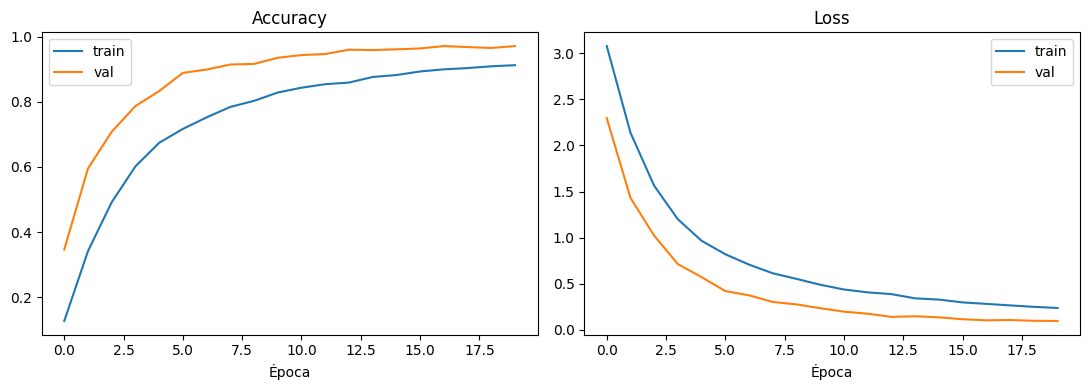

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.show()

## Evaluación en test

In [6]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy en test: {test_acc:.4f}")
print(f"Loss en test: {test_loss:.4f}")

Accuracy en test: 0.9644
Loss en test: 0.1150


In [7]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

           A       0.94      0.94      0.94        90
           B       0.97      1.00      0.98        90
           C       1.00      0.99      0.99        90
           D       0.98      0.97      0.97        90
           E       0.96      0.94      0.95        90
           F       1.00      1.00      1.00        90
           G       0.97      0.93      0.95        90
           H       0.93      0.96      0.95        90
           I       0.99      0.98      0.98        90
           J       0.95      0.99      0.97        90
           K       0.99      0.93      0.96        90
           L       0.98      0.99      0.98        90
           M       0.96      0.94      0.95        90
           N       0.97      0.96      0.96        90
           O       0.95      0.99      0.97        90
           P       0.99      0.97      0.98        90
           Q       1.00      0.99      0.99        90
           R       0.92    

## Matriz de confusión

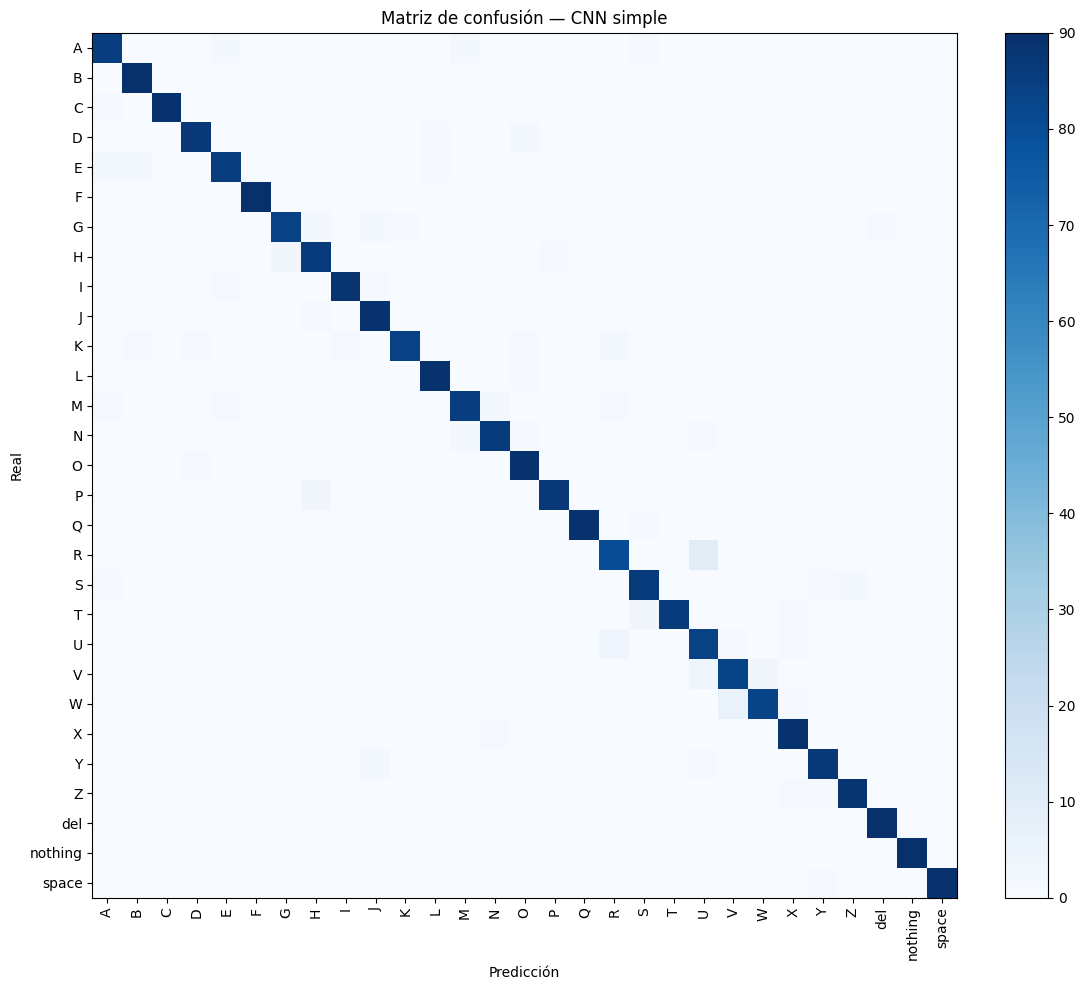

In [8]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(class_names, rotation=90)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — CNN simple")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## Guardar el modelo

Se guarda para poder compararlo con la CNN profunda y para probarlo más adelante con fotos propias (Ejercicio 8).

In [9]:
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

model.save(MODELS_DIR / "cnn_simple.keras")
print("Modelo guardado en", (MODELS_DIR / "cnn_simple.keras").resolve())

Modelo guardado en /Users/nilsmurallesmorales/universidad/octavosemestre/data/lab3/models/cnn_simple.keras
